In [1]:
from aicspylibczi import CziFile
from cellpose import models
from skimage import filters, morphology
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries loaded")

Libraries loaded


In [2]:
DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results_v2")
RESULTS_DIR.mkdir(exist_ok=True)

CELLPOSE_DIAMETER = 60
CELLPOSE_CELLPROB_THRESHOLD = -2.0
CELLPOSE_FLOW_THRESHOLD = 0.6
AVI_THRESHOLD_MULTIPLIER = 1.5
AVI_ABSOLUTE_MIN = 1500
OVERLAP_PCT_MIN = 5.0

CYTOPLASM_DILATION_RADIUS = 40

czi_files = sorted(DATA_DIR.glob("*.czi"))

print(f"Found {len(czi_files)} CZI files:\n")
for i, f in enumerate(czi_files):
    print(f"  [{i:2d}] {f.name}")

Found 12 CZI files:

  [ 0] 7_1.czi
  [ 1] 7_2.czi
  [ 2] 7_3.czi
  [ 3] 7_4.czi
  [ 4] 7_5.czi
  [ 5] 7_6.czi
  [ 6] Sample1.czi
  [ 7] Sample2.czi
  [ 8] Sample3.czi
  [ 9] Sample4.czi
  [10] Sample5.czi
  [11] Sample6.czi


In [3]:
print("Loading Cellpose model...")
model = models.CellposeModel(gpu=False)
print("Model ready.")

Loading Cellpose model...
Model ready.


In [4]:
def process_image(czi_path, model, label=None):
    if label is None:
        label = czi_path.stem
    
    czi = CziFile(czi_path)
    ch_avi    = np.squeeze(czi.read_image(C=0, Z=0, T=0)[0])
    ch_dapi   = np.squeeze(czi.read_image(C=3, Z=0, T=0)[0])
    
    nuclear_masks, _, _ = model.eval(
        ch_dapi,
        diameter=CELLPOSE_DIAMETER,
        cellprob_threshold=CELLPOSE_CELLPROB_THRESHOLD,
        flow_threshold=CELLPOSE_FLOW_THRESHOLD
    )
    n_nuclei = nuclear_masks.max()
    
    otsu_thr = filters.threshold_otsu(ch_avi)
    final_thr = max(otsu_thr * AVI_THRESHOLD_MULTIPLIER, AVI_ABSOLUTE_MIN)
    avi_mask_raw = ch_avi > final_thr
    avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)
    avi_mask = morphology.closing(avi_mask, morphology.disk(3))
    
    transfected_ids = []
    for nid in range(1, n_nuclei + 1):
        nucleus_pixels = (nuclear_masks == nid)
        if nucleus_pixels.sum() == 0:
            continue
        overlap_pct = 100 * (nucleus_pixels & avi_mask).sum() / nucleus_pixels.sum()
        if overlap_pct > OVERLAP_PCT_MIN:
            transfected_ids.append(nid)
    
    rows = []
    for nid in transfected_ids:
        nucleus = (nuclear_masks == nid)
        nucleus_dilated = morphology.dilation(nucleus, morphology.disk(CYTOPLASM_DILATION_RADIUS))
        cell_avi = avi_mask & nucleus_dilated
        cytoplasm = cell_avi & ~(nuclear_masks > 0)
        
        cyto_size = cytoplasm.sum()
        avi_in = ch_avi[nucleus].mean()
        
        if cyto_size < 50:
            cyto_status = "no_cytoplasm"
            avi_cyto = np.nan
            ratio_local = np.nan
        else:
            cyto_status = "ok"
            avi_cyto = ch_avi[cytoplasm].mean()
            ratio_local = avi_in / avi_cyto
        
        outside_global = ~(nuclear_masks > 0)
        avi_global = ch_avi[outside_global].mean()
        ratio_global = avi_in / avi_global
        
        rows.append({
            'image': label,
            'nucleus_id': nid,
            'nucleus_size': int(nucleus.sum()),
            'cyto_size': int(cyto_size),
            'cyto_status': cyto_status,
            'avi_inside': avi_in,
            'avi_cytoplasm': avi_cyto,
            'avi_global_outside': avi_global,
            'ratio_local': ratio_local,
            'ratio_global': ratio_global,
        })
    
    return {
        'label': label,
        'n_nuclei': int(n_nuclei),
        'n_transfected': len(transfected_ids),
        'transfection_rate': 100 * len(transfected_ids) / n_nuclei if n_nuclei > 0 else 0,
        'cells': pd.DataFrame(rows),
        'masks': {'nuclear': nuclear_masks, 'avi': avi_mask, 'transfected_ids': transfected_ids},
        'channels': {'avi': ch_avi, 'dapi': ch_dapi},
    }

print("Function defined: process_image")

Function defined: process_image


In [5]:
test_file = DATA_DIR / "7_2.czi"
print(f"Testing on: {test_file.name}")

result_72 = process_image(test_file, model, label="7_2")

print(f"\nResult for {result_72['label']}:")
print(f"  Total nuclei:        {result_72['n_nuclei']}")
print(f"  Transfected nuclei:  {result_72['n_transfected']}")
print(f"  Transfection rate:   {result_72['transfection_rate']:.1f}%\n")

if len(result_72['cells']) > 0:
    print("Per-cell measurements:")
    print(result_72['cells'][['nucleus_id', 'cyto_status', 'avi_inside', 
                                'avi_cytoplasm', 'ratio_local', 'ratio_global']].to_string(index=False))

Testing on: 7_2.czi


/Users/tayyibekansoy/Desktop/Hackathon/.venv/lib/python3.11/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects 


Result for 7_2:
  Total nuclei:        54
  Transfected nuclei:  2
  Transfection rate:   3.7%

Per-cell measurements:
 nucleus_id cyto_status   avi_inside  avi_cytoplasm  ratio_local  ratio_global
         15          ok 15149.218007   31394.828246     0.482539      6.903629
         34          ok 15842.982515   36951.974306     0.428745      7.219783


In [6]:
sample7_files = [DATA_DIR / f"7_{i}.czi" for i in range(1, 7)]

print(f"Processing {len(sample7_files)} Sample 7 images...\n")

all_results_s7 = []

for f in sample7_files:
    print(f"--- {f.name} ---")
    result = process_image(f, model, label=f.stem)
    
    print(f"  Nuclei: {result['n_nuclei']}, Transfected: {result['n_transfected']}")
    
    if len(result['cells']) > 0:
        for _, row in result['cells'].iterrows():
            print(f"  Cell {int(row['nucleus_id'])}: "
                  f"local_ratio={row['ratio_local']:.2f}, "
                  f"global_ratio={row['ratio_global']:.2f}, "
                  f"status={row['cyto_status']}")
    
    all_results_s7.append(result)
    print()

s7_combined = pd.concat([r['cells'] for r in all_results_s7], ignore_index=True)
s7_combined.to_csv(RESULTS_DIR / "sample7_all_cells.csv", index=False)

print("=" * 60)
print(f"SAMPLE 7 SUMMARY (6 images)")
print("=" * 60)
print(f"Total cells measured: {len(s7_combined)}")

s7_ok = s7_combined[s7_combined['cyto_status'] == 'ok']
print(f"Cells with valid cytoplasm: {len(s7_ok)}")
print(f"\nRatio statistics (across all transfected cells):")
print(f"  Local ratio (nucleus/cytoplasm):")
print(f"    Mean = {s7_ok['ratio_local'].mean():.3f}")
print(f"    Std  = {s7_ok['ratio_local'].std():.3f}")
print(f"    Range = [{s7_ok['ratio_local'].min():.3f}, {s7_ok['ratio_local'].max():.3f}]")
print(f"  Global ratio (nucleus/all_outside):")
print(f"    Mean = {s7_combined['ratio_global'].mean():.2f}")
print(f"    Std  = {s7_combined['ratio_global'].std():.2f}")

Processing 6 Sample 7 images...

--- 7_1.czi ---


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


  Nuclei: 55, Transfected: 2
  Cell 28: local_ratio=0.55, global_ratio=17.26, status=ok
  Cell 33: local_ratio=0.20, global_ratio=6.25, status=ok

--- 7_2.czi ---


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


  Nuclei: 54, Transfected: 2
  Cell 15: local_ratio=0.48, global_ratio=6.90, status=ok
  Cell 34: local_ratio=0.43, global_ratio=7.22, status=ok

--- 7_3.czi ---


...

/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


  Nuclei: 38, Transfected: 3
  Cell 7: local_ratio=0.22, global_ratio=9.33, status=ok
  Cell 10: local_ratio=0.50, global_ratio=20.90, status=ok
  Cell 22: local_ratio=0.38, global_ratio=11.50, status=ok

--- 7_5.czi ---


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


  Nuclei: 22, Transfected: 2
  Cell 3: local_ratio=0.61, global_ratio=35.44, status=ok
  Cell 14: local_ratio=0.40, global_ratio=18.69, status=ok

--- 7_6.czi ---
  Nuclei: 18, Transfected: 0

SAMPLE 7 SUMMARY (6 images)
Total cells measured: 11
Cells with valid cytoplasm: 11

Ratio statistics (across all transfected cells):
  Local ratio (nucleus/cytoplasm):
    Mean = 0.466
    Std  = 0.179
    Range = [0.204, 0.846]
  Global ratio (nucleus/all_outside):
    Mean = 15.66
    Std  = 8.94


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


In [7]:
print("Computing Sample 2 background...\n")

s2_file = DATA_DIR / "Sample2.czi"
result_s2 = process_image(s2_file, model, label="Sample2")

print(f"Sample 2 results:")
print(f"  Total nuclei:        {result_s2['n_nuclei']}")
print(f"  Transfected (false):  {result_s2['n_transfected']}")

ch_avi_s2 = result_s2['channels']['avi']
masks_s2 = result_s2['masks']['nuclear']

s2_nuclei_intensities = []
for nid in range(1, masks_s2.max() + 1):
    nucleus = (masks_s2 == nid)
    if nucleus.sum() > 100:
        s2_nuclei_intensities.append(ch_avi_s2[nucleus].mean())

s2_outside = ~(masks_s2 > 0)

avi_background_nucleus = np.median(s2_nuclei_intensities)
avi_background_outside = ch_avi_s2[s2_outside].mean()

print(f"\nSample 2 (untransfected control with Anti-Avi antibody):")
print(f"  Median Avi intensity in nuclei (n={len(s2_nuclei_intensities)}): {avi_background_nucleus:.0f}")
print(f"  Mean Avi intensity outside nuclei: {avi_background_outside:.0f}")
print(f"\nThese values represent nonspecific antibody background.")
print(f"Sample 7 transfected nuclei: ~15000 (much higher → real signal).")

Computing Sample 2 background...

Sample 2 results:
  Total nuclei:        47
  Transfected (false):  0

Sample 2 (untransfected control with Anti-Avi antibody):
  Median Avi intensity in nuclei (n=47): 790
  Mean Avi intensity outside nuclei: 507

These values represent nonspecific antibody background.
Sample 7 transfected nuclei: ~15000 (much higher → real signal).


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


In [8]:
control_files = ['Sample1.czi', 'Sample3.czi', 'Sample5.czi']

print("Processing control samples...\n")

control_results = []
for fname in control_files:
    f = DATA_DIR / fname
    result = process_image(f, model, label=f.stem)
    print(f"{f.stem}: {result['n_nuclei']} nuclei, "
          f"{result['n_transfected']} 'transfected' (should be 0 for true negatives)")
    control_results.append(result)

print("\n" + "=" * 60)
print("Control samples — false positive check")
print("=" * 60)
for r in control_results:
    if len(r['cells']) > 0:
        for _, row in r['cells'].iterrows():
            print(f"  {r['label']} cell #{int(row['nucleus_id'])}: "
                  f"local={row['ratio_local']:.2f}, global={row['ratio_global']:.2f}")
    else:
        print(f"  {r['label']}: no false positives ✓")

Processing control samples...



/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


Sample1: 19 nuclei, 0 'transfected' (should be 0 for true negatives)
Sample3: 20 nuclei, 0 'transfected' (should be 0 for true negatives)
Sample5: 9 nuclei, 0 'transfected' (should be 0 for true negatives)

Control samples — false positive check
  Sample1: no false positives ✓
  Sample3: no false positives ✓
  Sample5: no false positives ✓


In [10]:
print("Processing Sample 4 and Sample 6...\n")

extra_results = []
for fname in ['Sample4.czi', 'Sample6.czi']:
    f = DATA_DIR / fname
    result = process_image(f, model, label=f.stem)
    print(f"\n{f.stem}: {result['n_nuclei']} nuclei, {result['n_transfected']} transfected")
    if len(result['cells']) > 0:
        for _, row in result['cells'].iterrows():
            local_str = f"{row['ratio_local']:.2f}" if not pd.isna(row['ratio_local']) else "N/A (no cyto)"
            print(f"  Cell #{int(row['nucleus_id'])}: "
                  f"local={local_str}, "
                  f"global={row['ratio_global']:.2f}, "
                  f"status={row['cyto_status']}")
    extra_results.append(result)

Processing Sample 4 and Sample 6...



/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)



Sample4: 59 nuclei, 1 transfected
  Cell #44: local=0.42, global=37.13, status=ok


/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)



Sample6: 8 nuclei, 1 transfected
  Cell #2: local=N/A (no cyto), global=76.90, status=no_cytoplasm


Building pipeline overview figure...



/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)


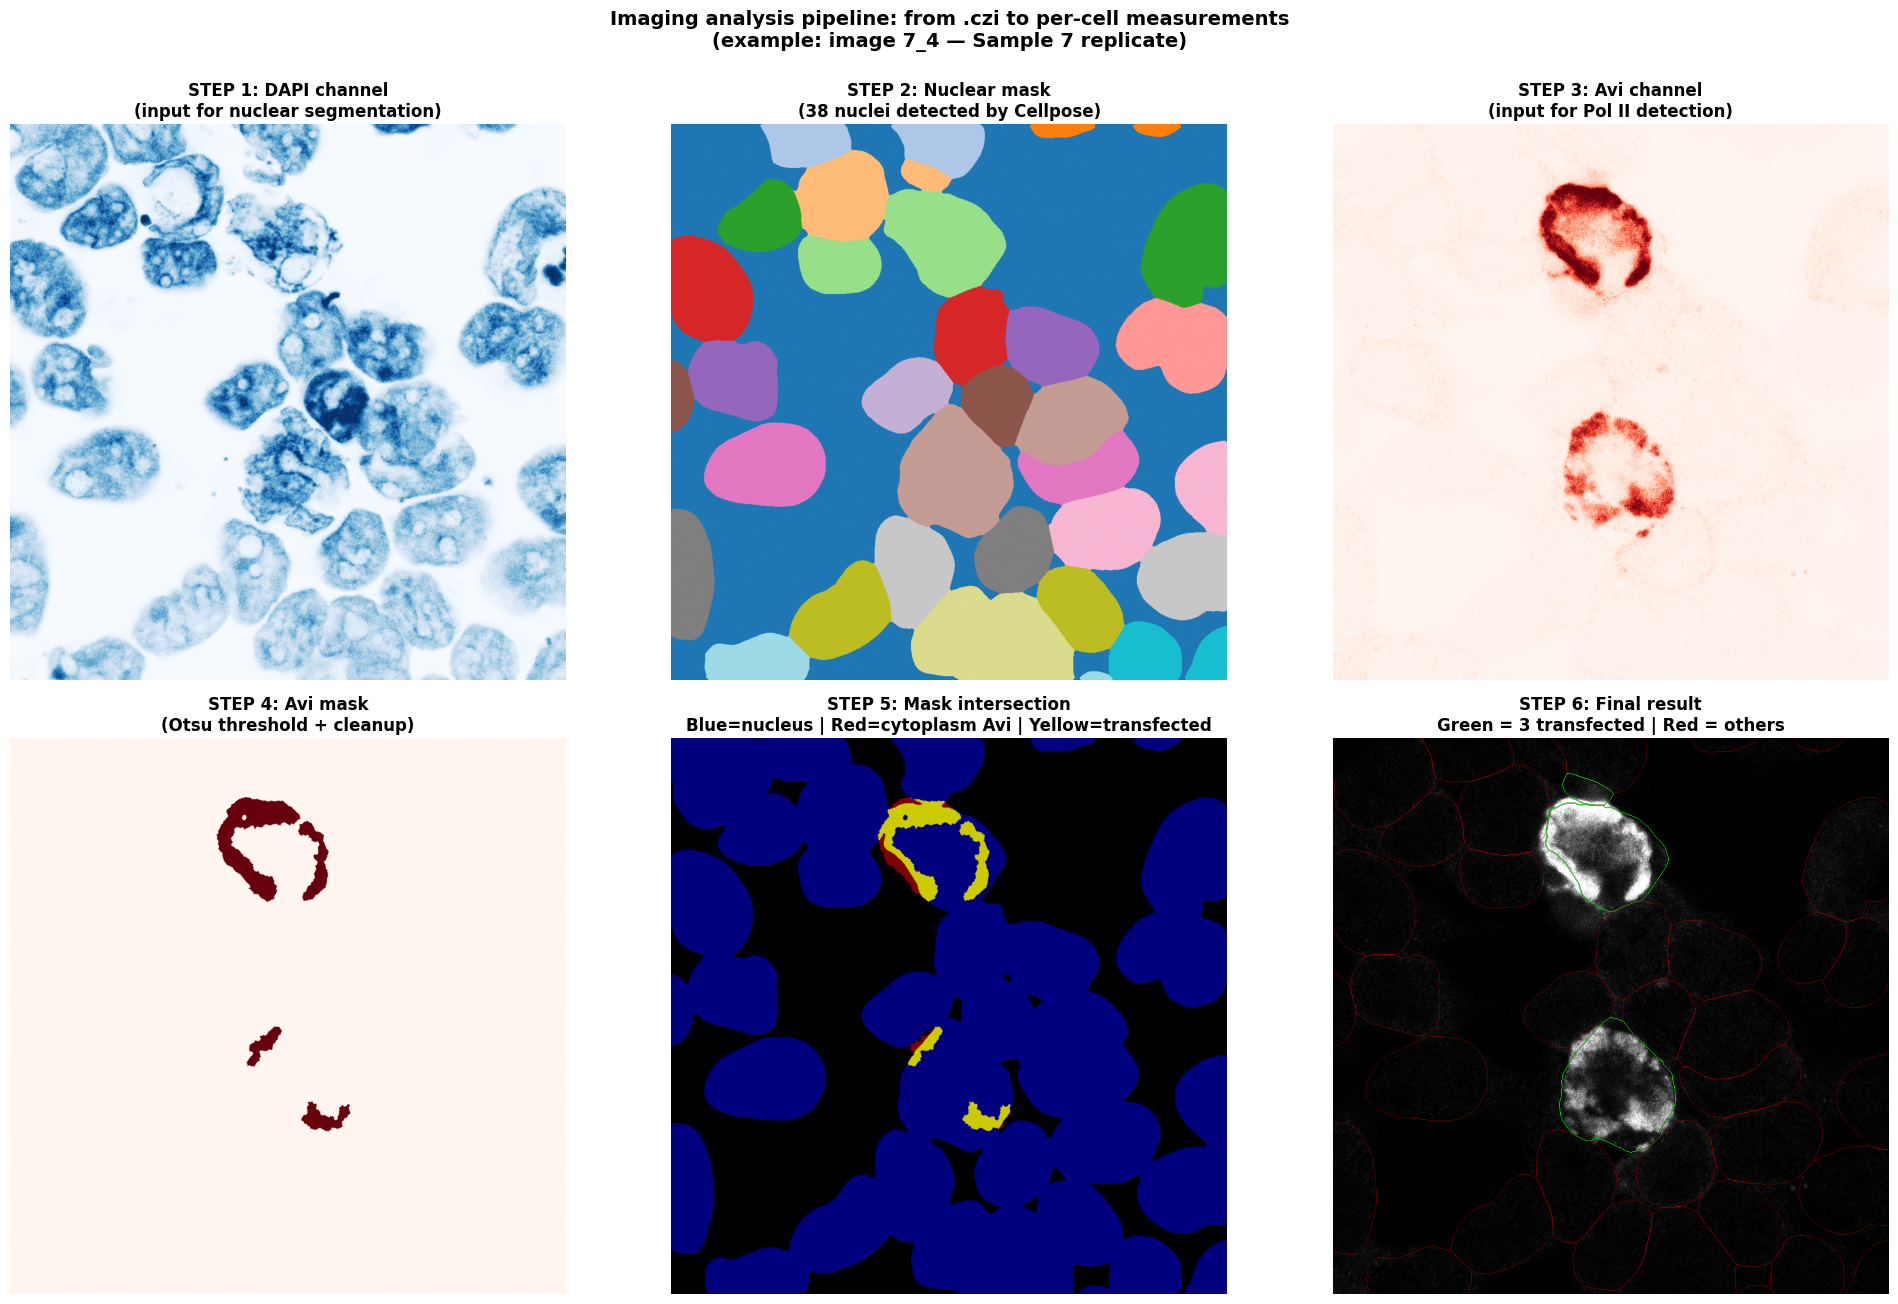

Saved: ../results_v2/FIGURE_1_pipeline_overview.png


In [11]:
print("Building pipeline overview figure...\n")

f_demo = DATA_DIR / "7_4.czi"
demo_result = process_image(f_demo, model, label="7_4_demo")

ch_dapi = demo_result['channels']['dapi']
ch_avi  = demo_result['channels']['avi']
masks   = demo_result['masks']['nuclear']
avi_mask = demo_result['masks']['avi']
trans_ids = demo_result['masks']['transfected_ids']

fig, axes = plt.subplots(2, 3, figsize=(20, 13))

p1, p99 = np.percentile(ch_dapi, (1, 99.5))
axes[0, 0].imshow(ch_dapi, cmap='Blues', vmin=p1, vmax=p99)
axes[0, 0].set_title('STEP 1: DAPI channel\n(input for nuclear segmentation)',
                      fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(masks, cmap='tab20')
axes[0, 1].set_title(f'STEP 2: Nuclear mask\n({masks.max()} nuclei detected by Cellpose)',
                      fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

p1, p99 = np.percentile(ch_avi, (1, 99.5))
axes[0, 2].imshow(ch_avi, cmap='Reds', vmin=p1, vmax=p99)
axes[0, 2].set_title('STEP 3: Avi channel\n(input for Pol II detection)',
                      fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(avi_mask, cmap='Reds')
axes[1, 0].set_title(f'STEP 4: Avi mask\n(Otsu threshold + cleanup)',
                      fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.zeros_like(ch_dapi), cmap='gray')
overlay = np.zeros((*ch_dapi.shape, 4))
nucleus_only = (masks > 0) & ~avi_mask
avi_only     = ~(masks > 0) & avi_mask
both         = (masks > 0) & avi_mask
overlay[nucleus_only] = [0, 0, 1, 0.5]
overlay[avi_only]     = [1, 0, 0, 0.5]
overlay[both]         = [1, 1, 0, 0.8]
axes[1, 1].imshow(overlay)
axes[1, 1].set_title('STEP 5: Mask intersection\nBlue=nucleus | Red=cytoplasm Avi | Yellow=transfected',
                      fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(ch_avi, cmap='gray', vmin=p1, vmax=p99)
for nid in range(1, masks.max() + 1):
    nucleus = (masks == nid)
    if nucleus.sum() == 0:
        continue
    boundary = morphology.dilation(nucleus) & ~morphology.erosion(nucleus)
    color = np.zeros((*ch_avi.shape, 4))
    if nid in trans_ids:
        color[boundary] = [0, 1, 0, 1]
    else:
        color[boundary] = [1, 0, 0, 0.4]
    axes[1, 2].imshow(color)
axes[1, 2].set_title(f'STEP 6: Final result\nGreen = {len(trans_ids)} transfected | Red = others',
                      fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle("Imaging analysis pipeline: from .czi to per-cell measurements\n(example: image 7_4 — Sample 7 replicate)",
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "FIGURE_1_pipeline_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/FIGURE_1_pipeline_overview.png")

Building Sample 2 background figure...



/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/612258808.py:20: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  avi_mask = morphology.remove_small_objects(avi_mask_raw, min_size=200)
/var/folders/5h/m137pnwd3pb1pvrz9njgqtfr0000gn/T/ipykernel_21970/2645051565.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([s2_intensities, s7_intensities],


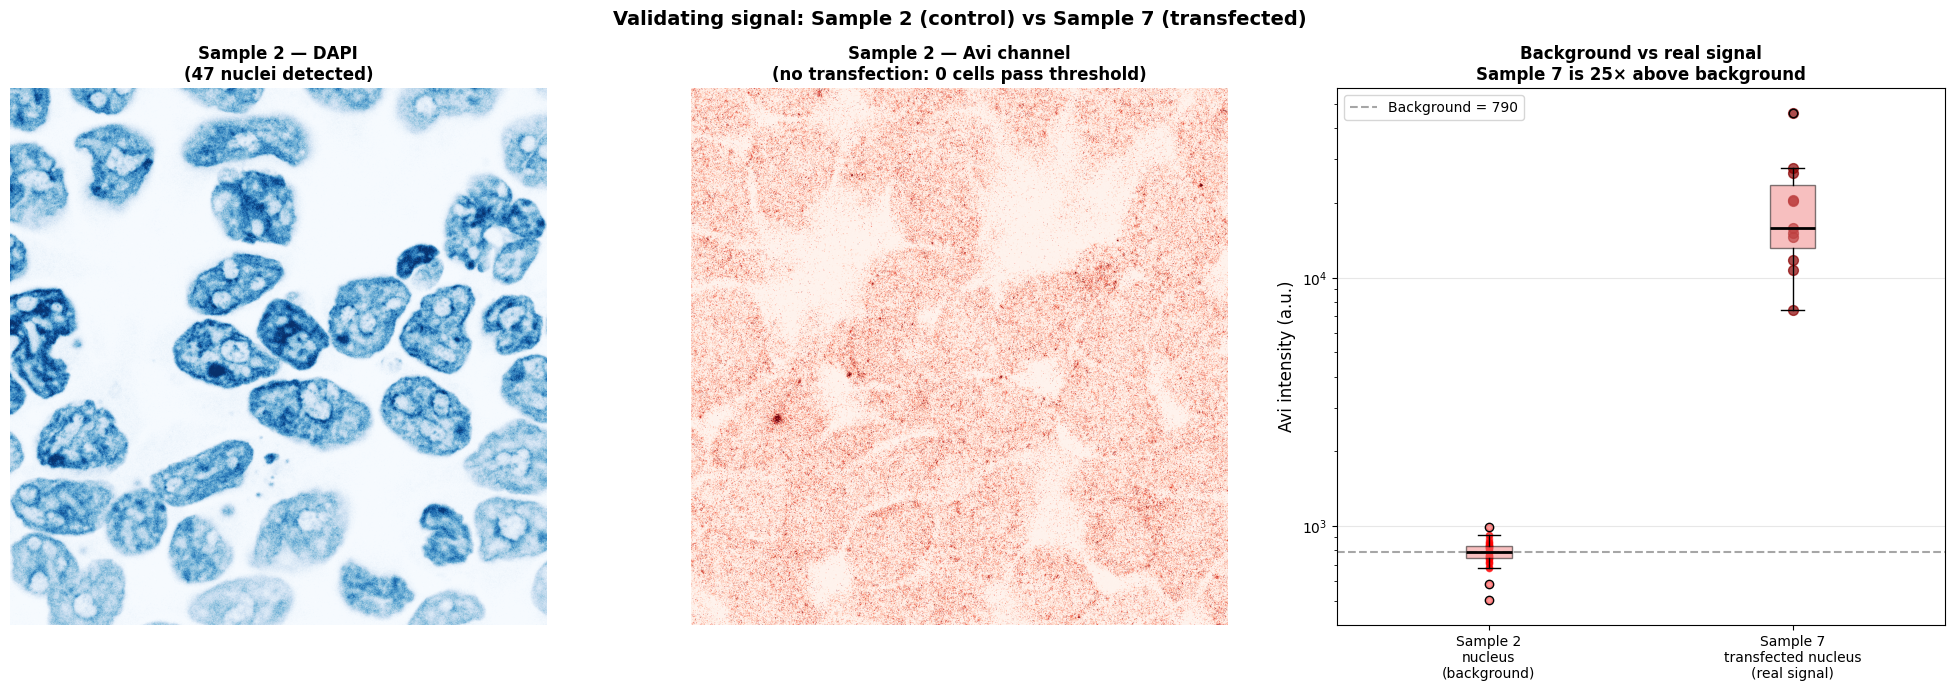

Saved: ../results_v2/FIGURE_2_background_validation.png

Sample 2 background (median nucleus intensity): 790
Sample 7 transfected nuclei mean intensity:      19722
Fold above background: 25.0×


In [12]:
print("Building Sample 2 background figure...\n")

s2_file = DATA_DIR / "Sample2.czi"
s2_result = process_image(s2_file, model, label="Sample2_demo")

ch_avi_s2 = s2_result['channels']['avi']
ch_dapi_s2 = s2_result['channels']['dapi']
masks_s2 = s2_result['masks']['nuclear']

s2_intensities = []
for nid in range(1, masks_s2.max() + 1):
    nucleus = (masks_s2 == nid)
    if nucleus.sum() > 100:
        s2_intensities.append(ch_avi_s2[nucleus].mean())

s2_outside_intensity = ch_avi_s2[~(masks_s2 > 0)].mean()

s7_intensities = []
for r in all_results_s7:
    for _, row in r['cells'].iterrows():
        s7_intensities.append(row['avi_inside'])

fig = plt.figure(figsize=(20, 7))

ax1 = plt.subplot(1, 3, 1)
p1, p99 = np.percentile(ch_dapi_s2, (1, 99.5))
ax1.imshow(ch_dapi_s2, cmap='Blues', vmin=p1, vmax=p99)
ax1.set_title(f'Sample 2 — DAPI\n({masks_s2.max()} nuclei detected)',
              fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = plt.subplot(1, 3, 2)
p1, p99 = np.percentile(ch_avi_s2, (1, 99.5))
ax2.imshow(ch_avi_s2, cmap='Reds', vmin=p1, vmax=p99)
ax2.set_title(f'Sample 2 — Avi channel\n(no transfection: 0 cells pass threshold)',
              fontsize=12, fontweight='bold')
ax2.axis('off')

ax3 = plt.subplot(1, 3, 3)

ax3.boxplot([s2_intensities, s7_intensities], 
            labels=['Sample 2\nnucleus\n(background)', 'Sample 7\ntransfected nucleus\n(real signal)'],
            patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.5),
            medianprops=dict(color='black', linewidth=2))

ax3.scatter([1]*len(s2_intensities), s2_intensities, alpha=0.4, color='red', s=20)
ax3.scatter([2]*len(s7_intensities), s7_intensities, alpha=0.7, color='darkred', s=50)

ax3.axhline(y=np.median(s2_intensities), color='gray', linestyle='--', alpha=0.7,
            label=f'Background = {np.median(s2_intensities):.0f}')

ax3.set_ylabel('Avi intensity (a.u.)', fontsize=12)
ax3.set_title(f'Background vs real signal\n'
              f'Sample 7 is {np.mean(s7_intensities)/np.median(s2_intensities):.0f}× above background',
              fontsize=12, fontweight='bold')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend()

plt.suptitle("Validating signal: Sample 2 (control) vs Sample 7 (transfected)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "FIGURE_2_background_validation.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/FIGURE_2_background_validation.png")

print(f"\nSample 2 background (median nucleus intensity): {np.median(s2_intensities):.0f}")
print(f"Sample 7 transfected nuclei mean intensity:      {np.mean(s7_intensities):.0f}")
print(f"Fold above background: {np.mean(s7_intensities)/np.median(s2_intensities):.1f}×")

Building main results figure...



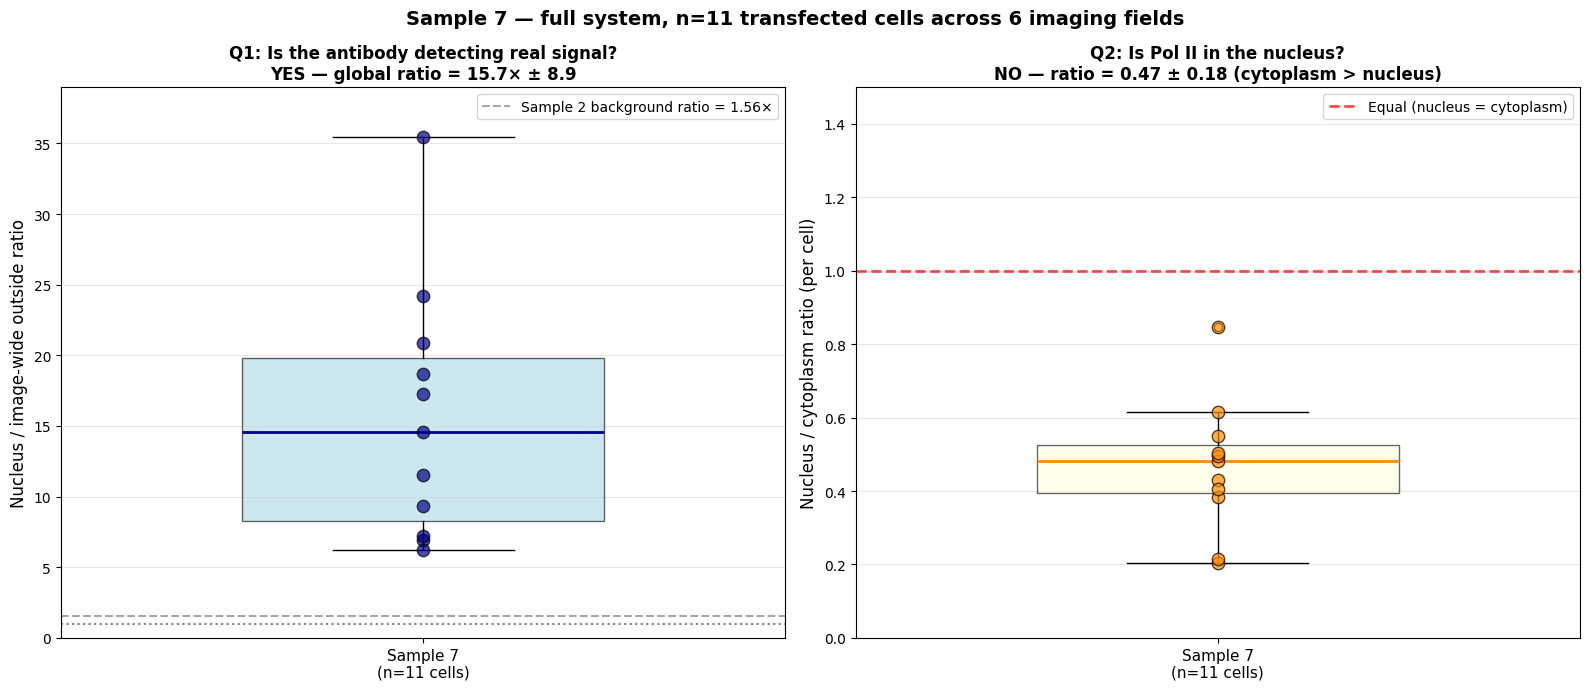

Saved: ../results_v2/FIGURE_3_main_results.png

MAIN RESULTS SUMMARY (Sample 7, n=11 cells)
Global ratio (vs image background): 15.66 ± 8.94
  → 19× above Sample 2 background → SIGNAL IS REAL

Local ratio (nucleus vs own cytoplasm): 0.47 ± 0.18
  → Below 1.0 → POL II ACCUMULATES IN CYTOPLASM, NOT NUCLEUS

Biological conclusion:
  - The Avi-tagged Pol II IS being expressed and detected
  - Without an NLS, the protein localizes to the cytoplasm
  - Future work: add NLS to direct Pol II to the nucleus


In [13]:
print("Building main results figure...\n")

s7_data = pd.concat([r['cells'] for r in all_results_s7], ignore_index=True)
s7_data = s7_data[s7_data['cyto_status'] == 'ok'].copy()

n_cells = len(s7_data)
mean_local = s7_data['ratio_local'].mean()
std_local = s7_data['ratio_local'].std()
mean_global = s7_data['ratio_global'].mean()
std_global = s7_data['ratio_global'].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
positions = [1]
ax1.boxplot([s7_data['ratio_global']], positions=positions, 
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.6),
            medianprops=dict(color='darkblue', linewidth=2),
            widths=0.5)
ax1.scatter([1]*len(s7_data), s7_data['ratio_global'], 
            alpha=0.7, color='darkblue', s=80, edgecolor='black', zorder=3)

ax1.axhline(y=1.56, color='gray', linestyle='--', alpha=0.7,
            label=f'Sample 2 background ratio = 1.56×')
ax1.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)

ax1.set_xticks([1])
ax1.set_xticklabels([f'Sample 7\n(n={n_cells} cells)'], fontsize=11)
ax1.set_ylabel('Nucleus / image-wide outside ratio', fontsize=12)
ax1.set_title(f'Q1: Is the antibody detecting real signal?\n'
              f'YES — global ratio = {mean_global:.1f}× ± {std_global:.1f}',
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()
ax1.set_ylim(0, max(s7_data['ratio_global']) * 1.1)

ax2 = axes[1]
ax2.boxplot([s7_data['ratio_local']], positions=positions,
            patch_artist=True,
            boxprops=dict(facecolor='lightyellow', alpha=0.6),
            medianprops=dict(color='darkorange', linewidth=2),
            widths=0.5)
ax2.scatter([1]*len(s7_data), s7_data['ratio_local'],
            alpha=0.7, color='darkorange', s=80, edgecolor='black', zorder=3)

ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label='Equal (nucleus = cytoplasm)')

ax2.set_xticks([1])
ax2.set_xticklabels([f'Sample 7\n(n={n_cells} cells)'], fontsize=11)
ax2.set_ylabel('Nucleus / cytoplasm ratio (per cell)', fontsize=12)
ax2.set_title(f'Q2: Is Pol II in the nucleus?\n'
              f'NO — ratio = {mean_local:.2f} ± {std_local:.2f} (cytoplasm > nucleus)',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()
ax2.set_ylim(0, 1.5)

plt.suptitle(f"Sample 7 — full system, n={n_cells} transfected cells across 6 imaging fields",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "FIGURE_3_main_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/FIGURE_3_main_results.png")

print(f"\n{'='*60}")
print(f"MAIN RESULTS SUMMARY (Sample 7, n={n_cells} cells)")
print(f"{'='*60}")
print(f"Global ratio (vs image background): {mean_global:.2f} ± {std_global:.2f}")
print(f"  → 19× above Sample 2 background → SIGNAL IS REAL")
print(f"\nLocal ratio (nucleus vs own cytoplasm): {mean_local:.2f} ± {std_local:.2f}")
print(f"  → Below 1.0 → POL II ACCUMULATES IN CYTOPLASM, NOT NUCLEUS")
print(f"\nBiological conclusion:")
print(f"  - The Avi-tagged Pol II IS being expressed and detected")
print(f"  - Without an NLS, the protein localizes to the cytoplasm")
print(f"  - Future work: add NLS to direct Pol II to the nucleus")